In [24]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os
from enum import Enum

range_real = [0, 1, 3, 4, 6, 7, 9, 10, 11, 12, 13]
range_alive = [1, 4, 9, 10, 11, 12, 13]
range_dead = [0, 3, 6, 7]

soil_variants = ['PR', 'T2']

soil_variants = ['PR']
rp = '/Users/pp/data/Simulations/PHS_GFO'
xd = xr.open_dataset(f"{rp}/Sens_Output_agg.nc")
df = pd.read_csv(f"{rp}/SwissParameterListWide_24_1000000.csv")

rtpath = 'out'
if not os.path.isdir(rtpath):
    os.mkdir(rtpath)

class State(Enum):
    Alive = 0
    Dead = 1

cols = ['psi_leaf_50_close','stem_hydraulic_capacitance', 'k_xylem_sat','huber_value',  'leaf_hydraulic_capacitance', 'leaf_area_index', 'g0', 'g1', 'k_soil_sat', 'camp_b', 'theta_s', 'camp_psi_soil_ref','jackson_root_beta','theta_emp_multiplier' , 'psi50_xylem', 'd_50_s']

cols = ['psi_leaf_50_close','stem_hydraulic_capacitance', 'k_xylem_sat','huber_value',  'leaf_hydraulic_capacitance', 'leaf_area_index', 'k_soil_sat', 'camp_b', 'camp_psi_soil_ref','jackson_root_beta', 'psi50_xylem', 'd_50_s']


colors  = ['tab:blue', 'tab:orange', 'tab:orange', 'tab:green', 'tab:orange', 'tab:green', 'tab:blue', 'tab:blue', 'tab:blue', 'tab:brown', 'tab:blue', 'tab:blue']
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

Training MLPRegressor...
done in 0.935s
Train R2 score: 1.00
Test R2 score: 0.99
Training MLPRegressor...
done in 0.913s
Train R2 score: 1.00
Test R2 score: 0.96
Training MLPRegressor...
done in 0.776s
Train R2 score: 1.00
Test R2 score: 1.00
Training MLPRegressor...
done in 0.802s
Train R2 score: 1.00
Test R2 score: 1.00


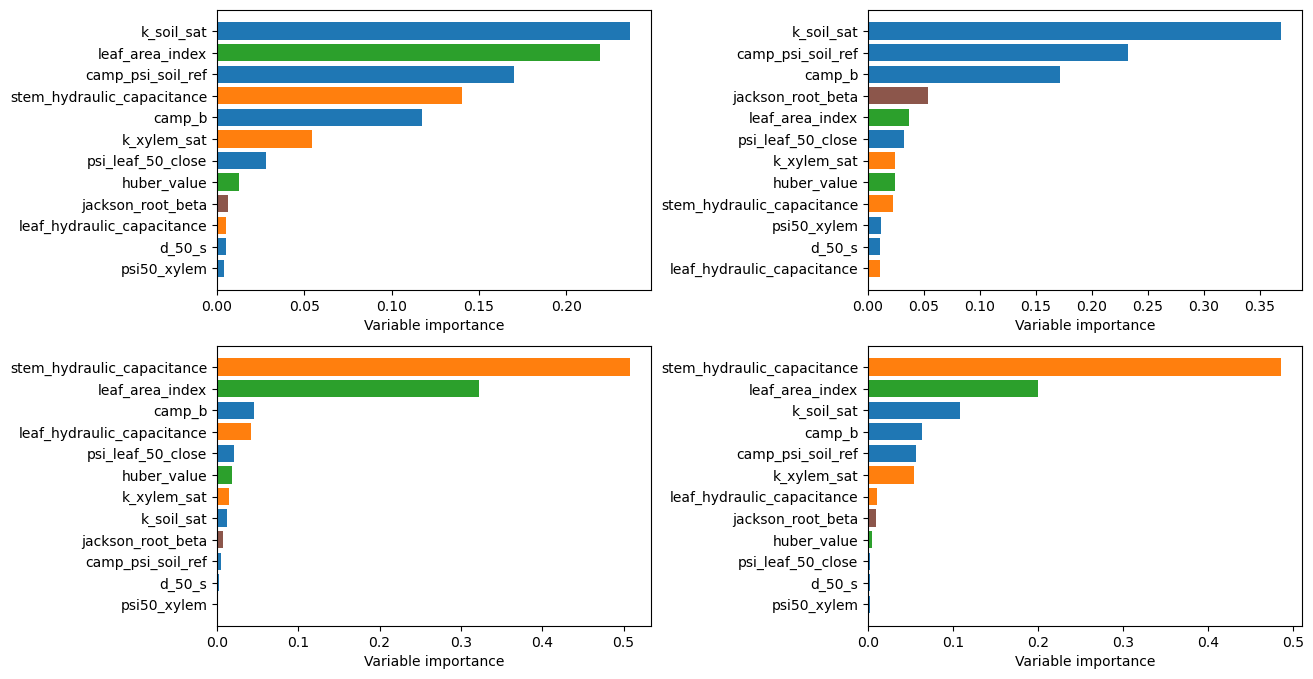

In [27]:
states = [State.Alive, State.Dead]
alive_state = [True, False]
for sv_i in range(len(soil_variants)):

        parameter_alive_file = f"{rt_path}/{soil_variants[sv_i]}_params_all_alive_rmse.csv"

        df_alive = pd.read_csv(parameter_alive_file)[0:1000]


        i = 1
        fig = plt.figure(figsize=(14,8))
        for k in range_dead:

            if k == 7:
                parameter_dead_file = f"{rt_path}/{soil_variants[sv_i]}_parameters_{k}_fix_rmse.csv"
            else:
                parameter_dead_file = f"{rt_path}/{soil_variants[sv_i]}_parameters_{k}_rmse.csv"


            df_dead = pd.read_csv(parameter_dead_file)[0:1000]

            df_alive['alive'] = 1
            df_dead['alive'] = 0
            df = pd.DataFrame(np.vstack([df_alive, df_dead]), columns=df_alive.columns)

            X_train, X_test, y_train, y_test = train_test_split(df[cols], df['alive'], test_size=0.20, random_state=42)

            from time import time
            print("Training MLPRegressor...")
            tic = time()
            est = RandomForestClassifier(n_estimators=1000, random_state=42, n_jobs=4, max_depth=10, class_weight = "balanced", bootstrap=True)
            est.fit(X_train, y_train)
            print(f"done in {time() - tic:.3f}s")
            print(f"Train R2 score: {est.score(X_train, y_train):.2f}")
            print(f"Test R2 score: {est.score(X_test, y_test):.2f}")
            sorted_idx = est.feature_importances_.argsort()

            sorted_idx = est.feature_importances_.argsort()

            ax = fig.add_subplot(2, 2, i)
            ax.barh(np.asarray(cols)[sorted_idx], est.feature_importances_[sorted_idx], color = np.asarray(colors)[sorted_idx])
            ax.set_xlabel('Variable importance')

            i+=1
        plt.subplots_adjust(wspace=0.5)

        plt.savefig(fname =f"{rt_path}/{soil_variants[sv_i]}_RF_Varimportances.png", dpi = 200, bbox_inches='tight', pad_inches=0)
        plt.show()



In [15]:
from sklearn.inspection import permutation_importance
result = permutation_importance(
                                est, X_test,
                                y_test, n_repeats=100, random_state=42, n_jobs=6)

forest_importances = pd.Series(result.importances_mean, index=cols)
s = forest_importances.argsort
fi = forest_importances[s]

Training MLPRegressor...
done in 0.088s
Train R2 score: 1.00
Test R2 score: 0.99
Training MLPRegressor...
done in 0.093s
Train R2 score: 1.00
Test R2 score: 0.96
Training MLPRegressor...
done in 0.078s
Train R2 score: 1.00
Test R2 score: 1.00
Training MLPRegressor...
done in 0.080s
Train R2 score: 1.00
Test R2 score: 1.00


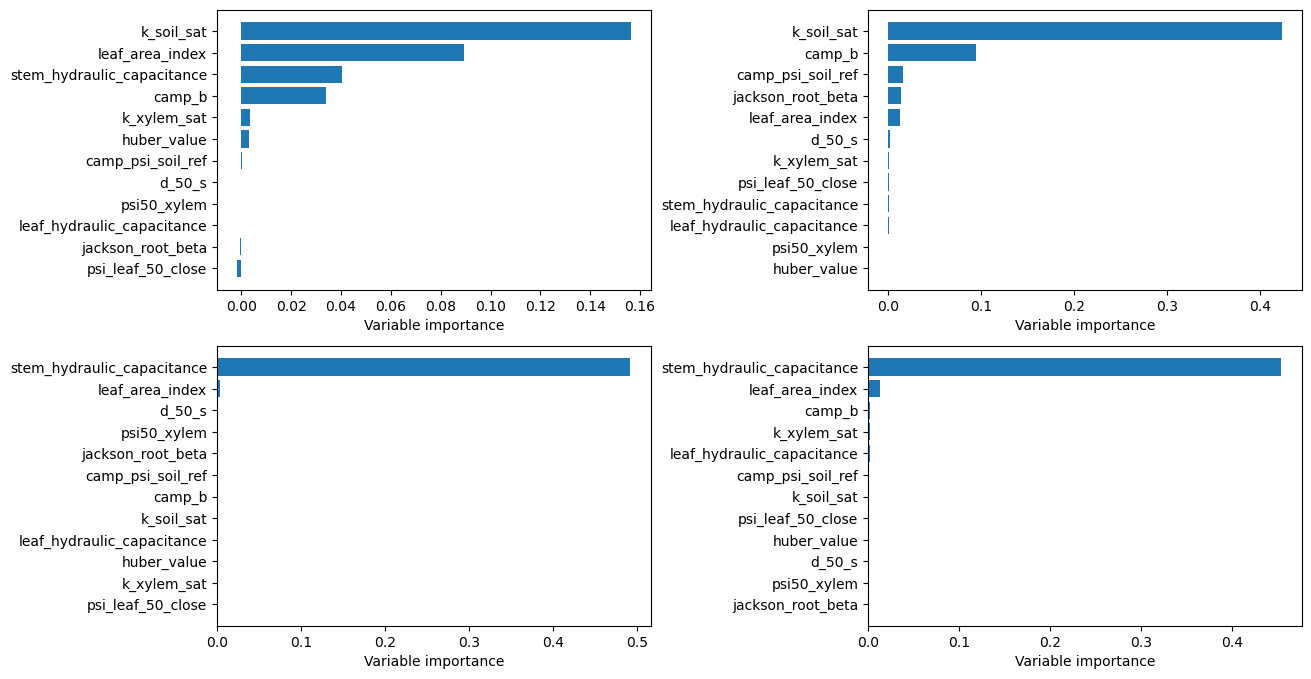

In [16]:
states = [State.Alive, State.Dead]
alive_state = [True, False]
for sv_i in range(len(soil_variants)):

        parameter_alive_file = f"{rt_path}/{soil_variants[sv_i]}_params_all_alive_rmse.csv"

        df_alive = pd.read_csv(parameter_alive_file)[0:1000]


        i = 1
        fig = plt.figure(figsize=(14,8))
        for k in range_dead:

            if k == 7:
                parameter_dead_file = f"{rt_path}/{soil_variants[sv_i]}_parameters_{k}_fix_rmse.csv"
            else:
                parameter_dead_file = f"{rt_path}/{soil_variants[sv_i]}_parameters_{k}_rmse.csv"


            df_dead = pd.read_csv(parameter_dead_file)[0:1000]

            df_alive['alive'] = 1
            df_dead['alive'] = 0
            df = pd.DataFrame(np.vstack([df_alive, df_dead]), columns=df_alive.columns)

            X_train, X_test, y_train, y_test = train_test_split(df[cols], df['alive'], test_size=0.20, random_state=42)

            from time import time
            print("Training MLPRegressor...")
            tic = time()
            est = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=4, max_depth=10, class_weight = "balanced", bootstrap=True)
            est.fit(X_train, y_train)
            print(f"done in {time() - tic:.3f}s")
            print(f"Train R2 score: {est.score(X_train, y_train):.2f}")
            print(f"Test R2 score: {est.score(X_test, y_test):.2f}")


            result = permutation_importance(
                                            est, X_test,
                                            y_test, n_repeats=100, random_state=42, n_jobs=6)

            forest_importances = pd.Series(result.importances_mean, index=cols)
            s = forest_importances.argsort
            fi = forest_importances[s]

            ax = fig.add_subplot(2, 2, i)
            ax.barh(fi.keys(),  fi)
            ax.set_xlabel('Variable importance')

            i+=1
        plt.subplots_adjust(wspace=0.5)

        plt.savefig(fname =f"{rt_path}/{soil_variants[sv_i]}_RF_ACC_DEC_Varimportances.png", dpi = 200, bbox_inches='tight', pad_inches=0)
        plt.show()